In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [72]:
train = pd.read_csv('Titanic_train.csv')
test = pd.read_csv('Titanic_test.csv')

In [73]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [74]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


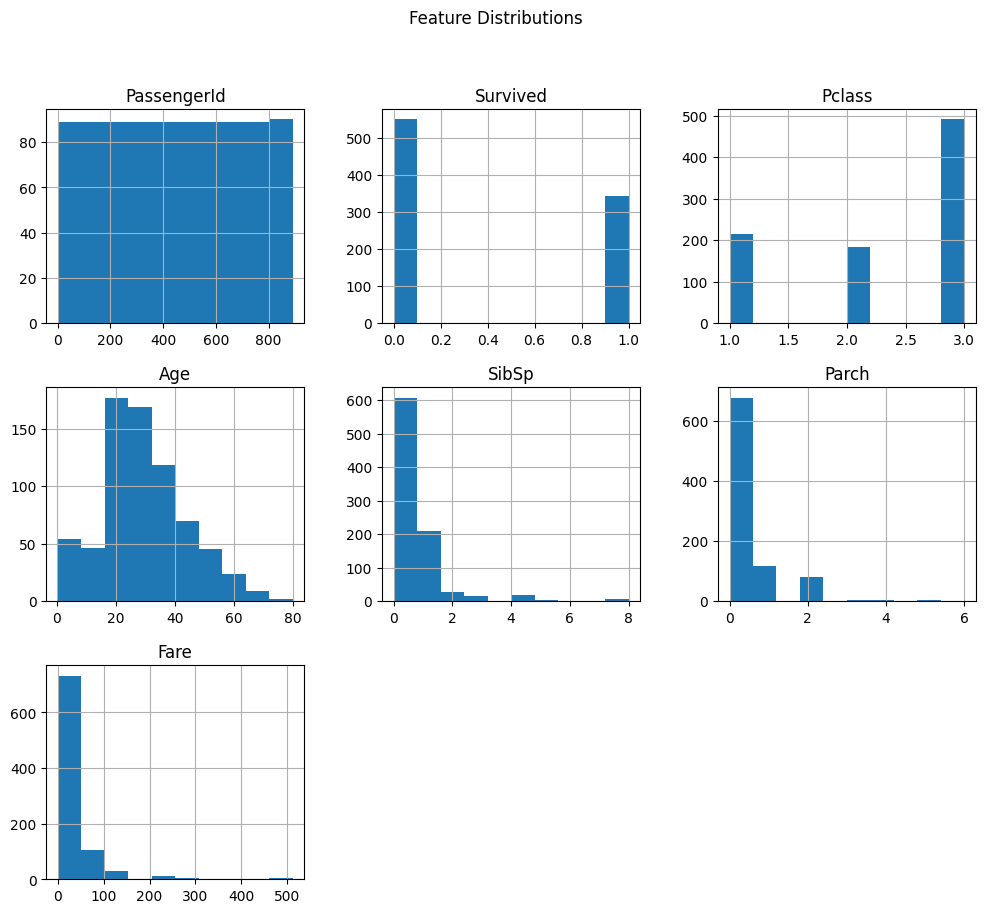

In [75]:
train.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

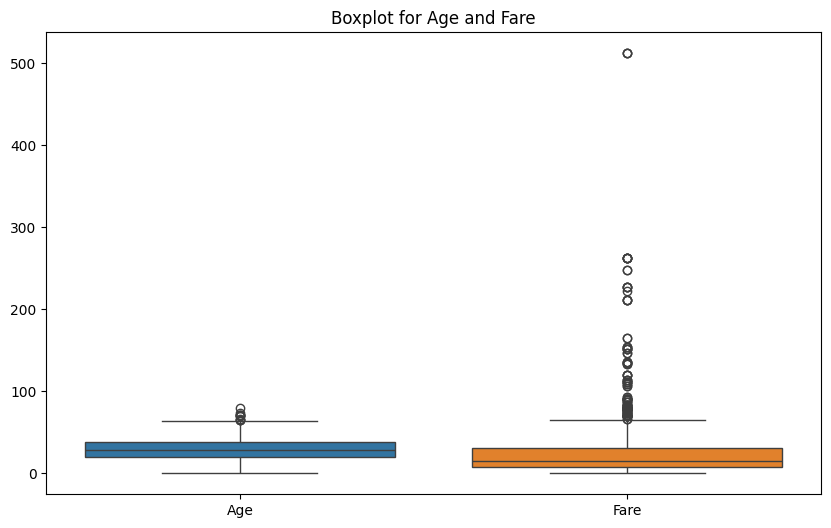

In [76]:
plt.figure(figsize=(10,6))
sns.boxplot(data=train[['Age','Fare']])
plt.title("Boxplot for Age and Fare")
plt.show()

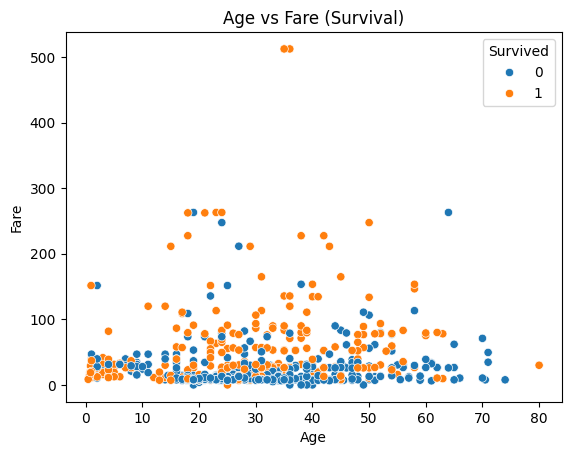

In [77]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train)
plt.title("Age vs Fare (Survival)")
plt.show()

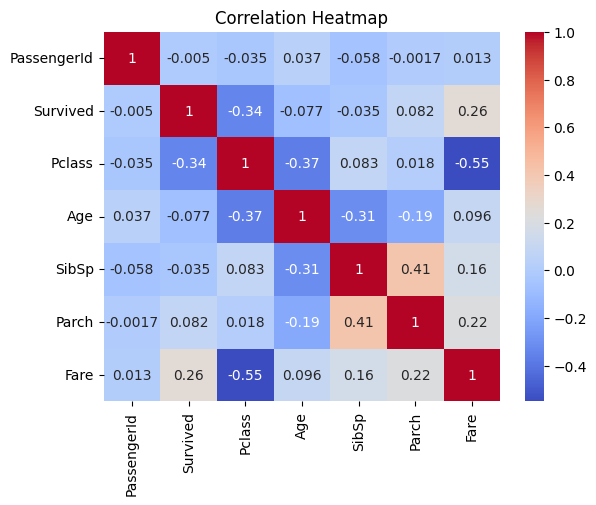

In [78]:
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [79]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [80]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


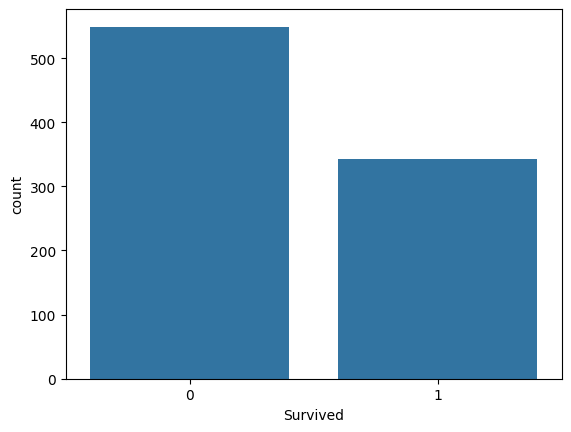

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=train)
plt.show()

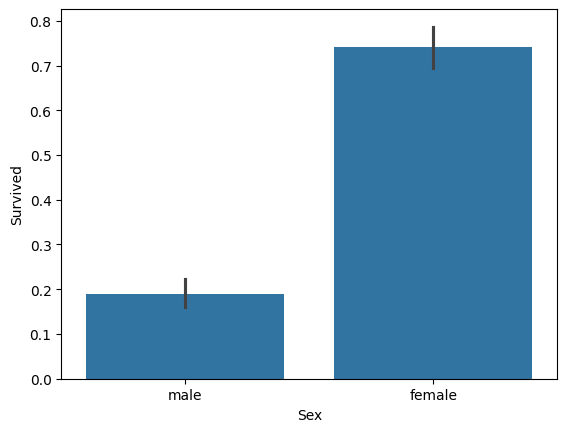

In [82]:
sns.barplot(x='Sex', y='Survived', data=train)
plt.show()

In [83]:
train['source'] = 'train'
test['source'] = 'test'

data = pd.concat([train, test], ignore_index=True)

In [84]:
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Fare'].fillna(data['Fare'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

data.drop(columns=['Cabin'], inplace=True)

/tmp/ipykernel_9387/3231187699.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_9387/3231187699.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [85]:
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

In [86]:
data.drop(columns=['Name', 'Ticket'], inplace=True)

In [87]:
train = data[data['source'] == 'train']
test = data[data['source'] == 'test']

train.drop(columns=['source'], inplace=True)
test.drop(columns=['source', 'Survived'], inplace=True)

/tmp/ipykernel_9387/3148746948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.drop(columns=['source'], inplace=True)
/tmp/ipykernel_9387/3148746948.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(columns=['source', 'Survived'], inplace=True)


In [88]:
X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [89]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
lgbm = LGBMClassifier(random_state=42)

xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

pred1 = xgb.predict(X_val)
pred2 = lgbm.predict(X_val)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 433
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [90]:
from sklearn.metrics import accuracy_score, classification_report

print("XGB Accuracy:", accuracy_score(y_val, pred1))
print("LGBM Accuracy:", accuracy_score(y_val, pred2))

print("\nXGB Report:\n", classification_report(y_val, pred1))
print("\nLGBM Report:\n", classification_report(y_val, pred2))

XGB Accuracy: 0.7932960893854749
LGBM Accuracy: 0.7988826815642458

XGB Report:
               precision    recall  f1-score   support

         0.0       0.82      0.83      0.82       105
         1.0       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179


LGBM Report:
               precision    recall  f1-score   support

         0.0       0.81      0.86      0.83       105
         1.0       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [91]:
print("XGB CV:", cross_val_score(xgb, X, y, cv=5).mean())

XGB CV: 0.7790345866549494


In [92]:
print("LGBM CV:", cross_val_score(lgbm, X, y, cv=5).mean())

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 441
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [93]:
param_grid = {
    'n_estimators': [50,100],
    'max_depth': [3,5],
    'learning_rate': [0.01,0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
data['Age'] = data['Age'].fillna(data['Age'].median())

In [96]:
X_test_final = X_test_final[X.columns]

In [97]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
lgbm = LGBMClassifier(random_state=42)

In [98]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

xgb.fit(X_train, y_train)
pred1 = xgb.predict(X_val)

lgbm.fit(X_train, y_train)
pred2 = lgbm.predict(X_val)

print("XGB Accuracy:", accuracy_score(y_val, pred1))
print("LGBM Accuracy:", accuracy_score(y_val, pred2))

[LightGBM] [Info] Number of positive: 276, number of negative: 436
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 445
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.387640 -> initscore=-0.457241
[LightGBM] [Info] Start training from score -0.457241
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


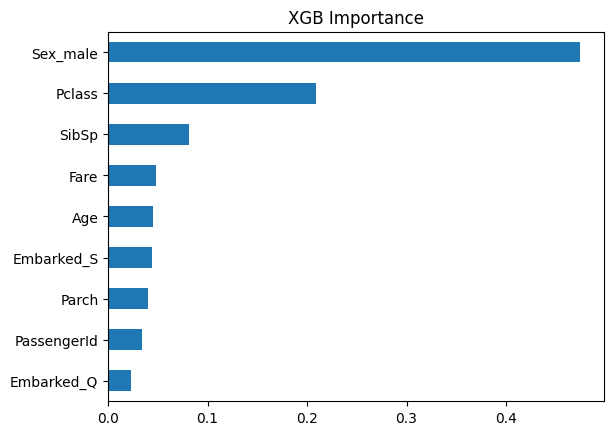

In [99]:
pd.Series(xgb.feature_importances_, index=X.columns)\
.sort_values().plot(kind='barh', title="XGB Importance")
plt.show()

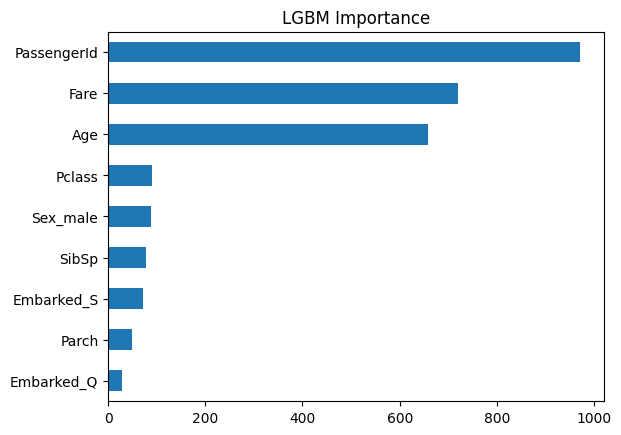

In [100]:
pd.Series(lgbm.feature_importances_, index=X.columns)\
.sort_values().plot(kind='barh', title="LGBM Importance")
plt.show()

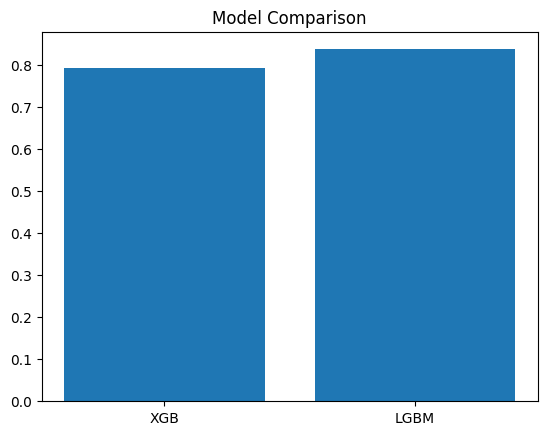

In [101]:
plt.bar(['XGB','LGBM'], [
    accuracy_score(y_val, pred1),
    accuracy_score(y_val, pred2)
])
plt.title("Model Comparison")
plt.show()

In [102]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': lgbm_pred   # or xgb_pred
})

submission.to_csv('submission.csv', index=False)

Conclusion:

After improving the analysis, both models were evaluated using accuracy, precision, recall, and F1-score.

XGBoost:
- Performs slightly better in handling complex patterns
- More robust but slower

LightGBM:
- Faster training
- Comparable accuracy

Cross-validation confirms both models are stable.
Feature importance shows Fare, Sex, and Pclass are key factors.

Final Conclusion:
Both models perform well, but LightGBM is preferred for speed, while XGBoost is preferred for accuracy.